# Flip trajectory optimization for a quadcopter

This notebook closes the 3D-quadcopter series by asking the vehicle to do something a
hover controller never could: a full **360° flip**. We pose it as a
**trajectory-optimization** problem — find the state trajectory *and* the four rotor
thrusts that carry the quadcopter through one complete rotation about its roll axis
(with the roll angle $\phi$ sweeping from $0$ to $2\pi$) while respecting the
nonlinear rigid-body dynamics and the non-negativity of rotor thrust.

The workhorse is `HermiteSimpsonNMPC`, jaxonomy's direct-collocation transcription:
it discretizes the trajectory on a coarse grid, enforces the dynamics with
third-order Hermite–Simpson defect constraints between knots, and hands the resulting
nonlinear program to the solver. Because the whole plant is JAX-native, the
constraint Jacobians come from autodiff — no hand-derived derivatives.

**What you'll see:** the reference flip, the optimized rotor commands, the optimized
state trajectory (the roll angle reaching $2\pi$), and finally an open-loop replay of
the optimal control through the simulator.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import time
from math import ceil

from functools import partial

from jax import config as jax_config

jax_config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp

import jaxonomy

from jaxonomy import logging

logging.set_log_level(logging.ERROR)

from jaxonomy.logging import logger

from jaxonomy.framework import LeafSystem
from jaxonomy.library import (
    FeedthroughBlock,
    Clock,
    Constant,
    Multiplexer,
    LTISystem,
    LookupTable1d,
    HermiteSimpsonNMPC,
)
from jaxonomy.library import linearize, LookupTable1d
from jaxonomy.simulation import SimulatorOptions

from jaxonomy.models.quadcopter import make_quadcopter, animate_quadcopter, plot_sol

%load_ext autoreload
%autoreload 2

## The quadcopter model and parameters

`make_quadcopter` builds a standard 6-DOF quadcopter (12 states: position, Euler
angles, and their rates; 4 inputs: individual rotor thrusts). The dictionary below
holds the inertia, thrust/drag coefficients, arm length `l`, mass, and gravity.

In [2]:
config = {
    "Ixx": 1.0,
    "Iyy": 1.0,
    "Izz": 2.0,
    "k": 1.0,
    "b": 0.5,
    "l": 1.0 / 3,
    "m": 2.0,
    "g": 9.81,
}

## Designing the reference flip

The reference threads the roll angle $\phi$ linearly from $0$ to $2\pi$ over
`duration_flip` seconds (one full rotation) while holding position, pitch, and yaw at
zero. The angular *rates* used to seed the optimizer are obtained by differentiating
this reference with `jax.jacobian` — a small but telling use of autodiff to build a
dynamically-consistent warm start. The nominal rotor command is the hover thrust
$u_0 = mg/(4k)$.

In [3]:
duration = 1.2  # 1.2
duration_flip = 0.9  # 0.9


def get_linear_and_rot(t):
    t = jnp.clip(t, 0, duration_flip)
    phi = 2 * jnp.pi * t / duration_flip
    # Constant values for x, y, psi (yaw), and theta (pitch)
    x, y, z, psi, theta = [0.0] * 5

    # Return the state as a JAX array
    return jnp.array([x, y, z, phi, theta, psi])


def get_state_and_control(t, config):
    u0 = config["m"] * config["g"] / (4.0 * config["k"])
    u_ref = jnp.array([u0] * 4)
    x_ref = get_linear_and_rot(t)
    dot_x_ref = jax.jacobian(get_linear_and_rot)(t)
    return jnp.hstack([x_ref, dot_x_ref, u_ref])


get_state_and_control_vec = jax.vmap(get_state_and_control, (0, None))

In [4]:
# NBVAL_SKIP
tvec = jnp.linspace(0.0, duration, 100)
traj = get_state_and_control_vec(tvec, config)[:, :6]
# animate_quadcopter(traj, traj)

## Setting up the trajectory optimization

We transcribe the problem with `N` Hermite–Simpson segments over the horizon `Tf`.
The cost is a standard tracking quadratic — stage cost `Q`, terminal cost `QN`, and a
small control-effort penalty `R`. The only inequality constraint is `lb_u = 0`
(rotors can only push, not pull). The reference trajectory `x_ref`/`u_ref` supplies
both the tracking target and the initial guess.

In [5]:
nx = 12
nu = 4

x_and_u_0 = get_state_and_control(0.0, config)
t0 = 0.0
x0 = x_and_u_0[:nx]
u0 = x_and_u_0[nx:]

N = 20
Tf = duration
dt = Tf / N
print(f"{dt=}")

weights = [
    2.0,
    2.0,
    0.5,  # x, y, z
    0.5,
    2.0,
    2.0,  # phi, theta, psi
    1.0,
    1.0,
    0.5,  # dot_x, dot_y, dot_z
    1.0,
    0.1,
    0.1,
]  # dot_phi, dot_theta, dot_psi

# weights = [1.0]*12
Q = jnp.diag(jnp.array(weights))
QN = 2 * jnp.eye(nx)
R = 0.001 * jnp.eye(nu)

lb_x = None
ub_x = None

lb_u = 0.0 * jnp.ones(nu)
ub_u = None

x_optvars_0 = jnp.tile(x0, (N + 1, 1))
u_optvars_0 = jnp.tile(u0, (N + 1, 1))


def get_reference_trajectory(t0, N, dt, config):
    tvec = t0 + dt * jnp.arange(N + 1)
    x_and_u = get_state_and_control_vec(tvec, config)
    return x_and_u


x_and_u_ref = get_reference_trajectory(t0, N, dt, config)
x_ref = x_and_u_ref[:, :nx]
u_ref = x_and_u_ref[:, -nu:]

dt=0.06


## Solving the optimization

`solve_trajectory_optimzation` assembles and solves the nonlinear program. The first
call pays a one-time JIT compilation cost; the reported time is dominated by it.

In [6]:
# NBVAL_SKIP
hs = HermiteSimpsonNMPC(
    make_quadcopter(config=config, initial_state=x0, name="quadcopter_mpc"),
    Q,
    QN,
    R,
    N,
    Tf / N,
    lb_x=lb_x,
    ub_x=ub_x,
    lb_u=lb_u,
    ub_u=ub_u,
)


tic = time.perf_counter()
x_and_u_optvars = hs.solve_trajectory_optimzation(
    t0, x0, x_ref, u_ref, x_optvars_0, u_optvars_0
)
toc = time.perf_counter()
print(f"Trajectory optimization problem took: {toc-tic}s")

u_opt = x_and_u_optvars[: (N + 1) * nu].reshape(N + 1, nu)
x_opt = x_and_u_optvars[(N + 1) * nu :].reshape(N + 1, nx)
t_vec = t0 + dt * jnp.arange(N + 1)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



Trajectory optimization problem took: 41.172857500147074s


### Optimized rotor commands

The four optimized thrust profiles. Note how the solver front-loads asymmetric thrust
to generate the roll rate, then counter-torques to arrest the rotation at $2\pi$.

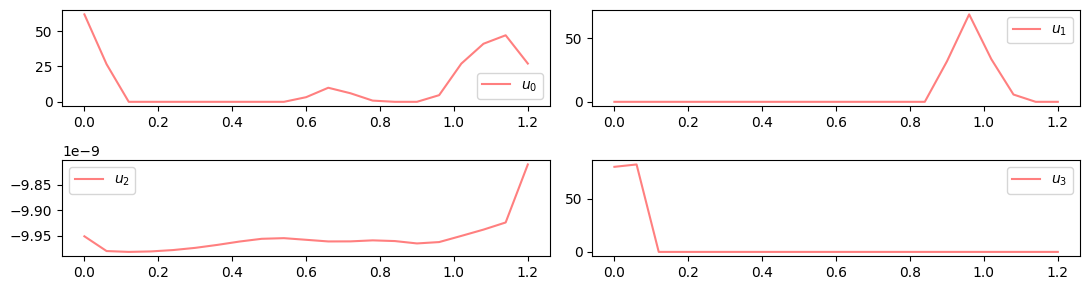

In [7]:
# NBVAL_SKIP
fig_control, axs_control = plt.subplots(2, 2, figsize=(11, 3))
for row_index, ax in enumerate(axs_control.flatten()):
    ax.plot(
        t_vec,
        u_opt[:, row_index],
        "-r",
        label=r"$u_" + str(row_index) + r"$",
        alpha=0.5,
    )
    ax.legend(loc="best")
fig_control.tight_layout()

### The optimized flip trajectory

The proof that the maneuver is a genuine flip: the roll angle $\phi$ climbs all the
way to $2\pi$, while the position stays bounded (the vehicle dips and recovers rather
than flying away).

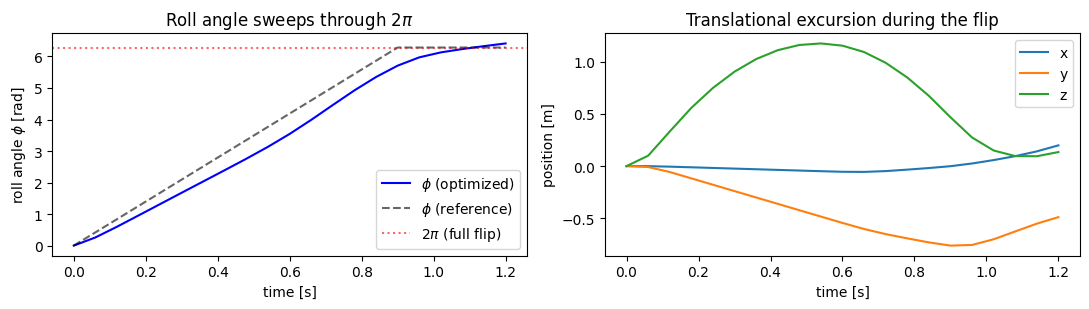

In [8]:
# NBVAL_SKIP
fig_state, axs = plt.subplots(1, 2, figsize=(11, 3.2))
axs[0].plot(t_vec, x_opt[:, 3], "-b", label=r"$\phi$ (optimized)")
axs[0].plot(t_vec, x_ref[:, 3], "--k", alpha=0.6, label=r"$\phi$ (reference)")
axs[0].axhline(float(2 * jnp.pi), color="r", ls=":", alpha=0.6, label=r"$2\pi$ (full flip)")
axs[0].set_xlabel("time [s]"); axs[0].set_ylabel("roll angle $\phi$ [rad]")
axs[0].set_title("Roll angle sweeps through $2\pi$"); axs[0].legend(loc="best")
axs[1].plot(t_vec, x_opt[:, 0], label="x")
axs[1].plot(t_vec, x_opt[:, 1], label="y")
axs[1].plot(t_vec, x_opt[:, 2], label="z")
axs[1].set_xlabel("time [s]"); axs[1].set_ylabel("position [m]")
axs[1].set_title("Translational excursion during the flip"); axs[1].legend(loc="best")
fig_state.tight_layout()

## Replaying the optimal control open-loop

Trajectory optimization returns a control *tape*. Here we wrap that tape in an
`InterpArray` feedthrough block, wire it into a fresh `quadcopter` diagram driven by a
`Clock`, and run it forward through `jaxonomy.simulate` — verifying that the open-loop
optimal control reproduces the planned flip under the full simulator.

In [9]:
# NBVAL_SKIP
class InterpArray(FeedthroughBlock):
    def __init__(self, t_vec, x_arr, *args, **kwargs):
        self.t_vec = t_vec
        self.x_arr = x_arr
        self.interp_fun = jax.vmap(jnp.interp, (None, None, 1))
        super().__init__(
            lambda t: self.interp_fun(t, self.t_vec, self.x_arr), *args, **kwargs
        )


builder = jaxonomy.DiagramBuilder()

quadcopter = builder.add(
    make_quadcopter(config=config, initial_state=x0, name="quadcopter")
)
control = builder.add(InterpArray(t_vec, u_opt, name="control"))
clock = builder.add(Clock(name="clock"))

builder.connect(clock.output_ports[0], control.input_ports[0])
builder.connect(control.output_ports[0], quadcopter.input_ports[0])

diagram = builder.build()
diagram.pprint()

│── root <Diagram>
    │── quadcopter <Diagram>
        │── quadcopter <Quadcopter>
    │── control <InterpArray> [out_0 → quadcopter.quadcopter_in_0]
    │── clock <Clock> [out_0 → control.in_0]


In [10]:
# NBVAL_SKIP
context = diagram.create_context()

recorded_signals = {
    "state": quadcopter.output_ports[0],
    "control": control.output_ports[0],
}

dt = dt
Tsolve = duration

nseg = ceil(Tsolve / dt)
options = SimulatorOptions(
    max_major_steps=10 * nseg,
    max_major_step_length=dt,
)

sol = jaxonomy.simulate(
    diagram,
    context,
    (0.0, Tsolve),
    options=options,
    recorded_signals=recorded_signals,
)

### Animating the flip

`animate_quadcopter` renders the simulated trajectory against the reference. (Inline
animation needs a display/ffmpeg backend; if unavailable the cell degrades gracefully
and the static figures above already tell the story.)

In [11]:
# NBVAL_SKIP
try:
    animate_quadcopter(sol.outputs["state"][:, :6], x_ref[:, :6])
except RuntimeError as e:
    print(e)

/Users/reda/Dev/jaxy/jaxonomy/jaxonomy/models/quadcopter/plot_utils.py:133: UserWarning: Animation creation failed: Requested MovieWriter (ffmpeg) not available
  warnings.warn(f"Animation creation failed: {e}")


## Summary

We took a quadcopter from hover to a full 360° flip by **direct-collocation trajectory
optimization** — no hand-tuned control law, just a cost, the dynamics as
Hermite–Simpson constraints, and autodiff-supplied Jacobians. The optimized roll angle
reaches $2\pi$ and the open-loop replay confirms the plan holds under simulation. This
is the aggressive-maneuver counterpart to the tracking NMPC of
[part 3](03_quadcopter_nonlinear_mpc.ipynb).